# 1. CONFIGURAÇÃO DO AMBIENTE E BIBLIOTECAS

In [84]:
# Pandas: Biblioteca padrão para manipulação de dados em tabelas (DataFrames)
import pandas as pd

# NumPy: Biblioteca para computação numérica de alto desempenho e vetorização de matrizes
import numpy as np

# Matplotlib.pyplot: Módulo essencial para plotagem de gráficos e exportação de figuras
import matplotlib.pyplot as plt

# Seaborn: Biblioteca de visualização estatística baseada no Matplotlib
import seaborn as sns

# SHAP: Biblioteca de IA Explicável baseada em Valores de Shapley (Teoria dos Jogos Cooperativos)
import shap

# Gzip: Utilitário para abrir e descompactar os arquivos compactados dos modelos (.gz)
import gzip

# Pickle: Biblioteca para ler e desserializar objetos Python salvos em disco
import pickle

# Copy: Permite realizar cópias profundas em memória, evitando mutações acidentais de objetos
import copy

# OS: Interface com o sistema operacional para gerenciamento de arquivos
import os

# Pathlib.Path: Abordagem orientada a objetos para gerenciar caminhos de diretórios de forma limpa
from pathlib import Path

# Datetime: Módulo para captura de carimbos de tempo (timestamps) e gerenciamento de datas
from datetime import datetime

# Importação de métricas oficiais do Scikit-Learn para validação do desempenho dos modelos
from sklearn.metrics import (
    confusion_matrix,        # Gera a matriz de confusão (TP, FP, TN, FN)
    ConfusionMatrixDisplay, # Plota graficamente a matriz de confusão
    accuracy_score,         # Calcula a taxa de acerto global do classificador
    precision_score,        # Calcula a precisão (relevante para monitorar Falsos Positivos)
    recall_score,           # Calcula o recall (relevante para monitorar Falsos Negativos)
    f1_score,               # Média harmônica balanceada entre precisão e recall
    classification_report   # Tabela textual com o resumo completo de métricas por classe
)

# Warnings: Desativa alertas de depreciação do ecossistema Python para manter o console limpo
import warnings
warnings.filterwarnings("ignore")

# RANDOM_STATE: Semente estável compartilhada para garantir reprodutibilidade matemática exata
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Bibliotecas carregadas e semente de reprodutibilidade configurada com sucesso.")

Bibliotecas carregadas e semente de reprodutibilidade configurada com sucesso.


# 2. DIRETÓRIOS, CARREGAMENTO DOS DADOS DE REDE E MODELOS

In [85]:
# Correção para manter compatibilidade com parâmetros legados de estratégias de amostragem
def get_sampling_strategy(*args, **kwargs):
    return "auto"

# PROJECT_ROOT: Sobe um nível em relação ao diretório de execução para mapear a raiz real do projeto
PROJECT_ROOT = Path.cwd().parent

# Definição dos caminhos absolutos dos subdiretórios de dados, resultados e relatórios do projeto
DATASET_DIR = PROJECT_ROOT / "datasense" / "dataset"
RESULTS_DIR = PROJECT_ROOT / "experiments" / "results"
EVAL_DIR = PROJECT_ROOT / "experiments" / "evaluations"
XAI_DIR = PROJECT_ROOT / "experiments" / "results_xai"

# Criação dinâmica e recursiva das pastas de saída, prevenindo erros de FileNotFoundError
SHAP_GLOBAL_DIR = XAI_DIR / "shap_global"
SHAP_MICRO_DIR = XAI_DIR / "shap_micro"
FPFN_BINARY_DIR = XAI_DIR / "fpfn_binary"
FPFN_MULTI_DIR = XAI_DIR / "fpfn_multiclass"
FIG_DIR = XAI_DIR / "figures"

for path in [SHAP_GLOBAL_DIR, SHAP_MICRO_DIR, FPFN_BINARY_DIR, FPFN_MULTI_DIR, FIG_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------------------------------
# CARREGAMENTO DO DATASET E RÓTULOS (FOCO EM BINÁRIO E 8 CLASSES)
# --------------------------------------------------------------------------
print("Carregando dataset de teste Parquet...")
dataset = pd.read_parquet(DATASET_DIR / "datasense_full_test_1sec.parquet")

print("="*60)
print("VERIFICAÇÃO DE DIRETÓRIOS")
print("="*60)
print("Dataset:", DATASET_DIR.exists())
print("Results:", RESULTS_DIR.exists())
print("Evaluations:", EVAL_DIR.exists())

# Extração dos alvos reais: label1 para binário, label2 para as 8 macroclasses do artigo
y_test_binary = dataset["label1"].copy()
y_test_multi = dataset["label2"].copy()

# Remove as colunas de rótulo para isolar estritamente o conjunto de features de tráfego (X_test)
X_test = dataset.drop(columns=["label1", "label2", "label3", "label4"], errors="ignore")
print(f"\nDimensões do X_test original: {X_test.shape}")

# --------------------------------------------------------------------------
# CARREGAMENTO DOS MODELOS
# --------------------------------------------------------------------------
MODEL_PATHS_BINARY = {
    "logistic_regression": RESULTS_DIR / "logistic_regression_full_all" / "pipe.pickle.gz",
    "decision_tree": RESULTS_DIR / "decision_tree_full_all" / "pipe.pickle.gz",
    "random_forest": RESULTS_DIR / "random_forest_full_all" / "pipe.pickle.gz"
}

MODEL_PATHS_MULTI = {
    "logistic_regression_multi": RESULTS_DIR / "logistic_regression_full_grouped" / "pipe.pickle.gz",
    "decision_tree_multi": RESULTS_DIR / "decision_tree_full_grouped" / "pipe.pickle.gz",
    "random_forest_multi": RESULTS_DIR / "random_forest_full_grouped" / "pipe.pickle.gz"
}

MODELS_BINARY = {}
print("\nCarregando modelos binários...")
for name, path in MODEL_PATHS_BINARY.items():
    with gzip.open(path, "rb") as f:
        MODELS_BINARY[name] = pickle.load(f)
    print(f"[OK] {name}")

MODELS_MULTI = {}
print("\nCarregando modelos multiclasses...")
for name, path in MODEL_PATHS_MULTI.items():
    with gzip.open(path, "rb") as f:
        MODELS_MULTI[name] = pickle.load(f)
    print(f"[OK] {name}")

# FEATURE ALIGNMENT: Alinha as colunas de X_test com o preprocessor do pipeline do projeto
ref_model = list(MODELS_MULTI.values())[0] if len(MODELS_MULTI) > 0 else list(MODELS_BINARY.values())[0]
if hasattr(ref_model, "named_steps") and "preprocessor" in ref_model.named_steps:
    try:
        expected_features = ref_model.named_steps["preprocessor"].feature_names_in_
    except:
        expected_features = X_test.columns
else:
    expected_features = X_test.columns

X_test = X_test.reindex(columns=expected_features, fill_value=0)
print(f"\nDataset alinhado com os pipelines. Dimensão final: {X_test.shape}")

# Carrega o arquivo CSV de importância de características padrão para checagem
feature_importance_df = pd.read_csv(EVAL_DIR / "feature_importances.csv")
print("\nFeature Importance carregado com sucesso.")

Carregando dataset de teste Parquet...
VERIFICAÇÃO DE DIRETÓRIOS
Dataset: True
Results: True
Evaluations: True

Dimensões do X_test original: (56798, 107)

Carregando modelos binários...
[OK] logistic_regression
[OK] decision_tree
[OK] random_forest

Carregando modelos multiclasses...
[OK] logistic_regression_multi
[OK] decision_tree_multi
[OK] random_forest_multi

Dataset alinhado com os pipelines. Dimensão final: (56798, 107)

Feature Importance carregado com sucesso.


In [86]:

# OBJETIVO:
#
# Carregar:
#
# 1) Dataset de teste
# 2) Modelos treinados
# 3) Resultados do evaluations
#
# JUSTIFICATIVA:
#
# O dataset é usado para SHAP
#
# Os modelos são necessários
# para calcular explicabilidade
#
# O evaluations fornece:
#
# métricas
# confusion matrices
# PCA
# t-SNE
#



PROJECT_ROOT=Path.cwd().parent


# ------------------------------------------------
# Caminhos reais do projeto
# ------------------------------------------------

DATASET_DIR=PROJECT_ROOT/"datasense"/"dataset"

RESULTS_DIR=PROJECT_ROOT/"experiments"/"results"

EVAL_DIR=PROJECT_ROOT/"experiments"/"evaluations"


print("="*60)

print("VERIFICAÇÃO")

print("="*60)

print("\nDataset:",DATASET_DIR.exists())

print("Results:",RESULTS_DIR.exists())

print("Evaluations:",EVAL_DIR.exists())


# ------------------------------------------------
# Carregar Dataset
# ------------------------------------------------

X_test=pd.read_parquet(

DATASET_DIR/
"datasense_full_test_1sec.parquet"

)


y_test=X_test["label4"].copy()


X_test=X_test.drop(

columns=[

"label1",
"label2",
"label4"

],

errors="ignore"

)

print("\nDataset:")

print(X_test.shape)



# ------------------------------------------------
# Carregar modelos
# ------------------------------------------------

MODELS={}


MODEL_PATHS={

"logistic_regression":

RESULTS_DIR/
"logistic_regression_full_all"/
"pipe.pickle.gz",


"decision_tree":

RESULTS_DIR/
"decision_tree_full_all"/
"pipe.pickle.gz",


"random_forest":

RESULTS_DIR/
"random_forest_full_all"/
"pipe.pickle.gz"

}



for name,path in MODEL_PATHS.items():

    print("\nCarregando:",name)

    with gzip.open(

    path,
    "rb"

    ) as f:

        MODELS[name]=pickle.load(
        f
        )


print("\nModelos carregados:")

print(MODELS.keys())


# ------------------------------------------------
# Carregar Feature Importance
# ------------------------------------------------

feature_importance=pd.read_csv(

EVAL_DIR/
"feature_importances.csv"

)

print("\nFeature importance carregado")

display(

feature_importance.head()

)

VERIFICAÇÃO

Dataset: True
Results: True
Evaluations: True

Dataset:
(56798, 108)

Carregando: logistic_regression

Carregando: decision_tree

Carregando: random_forest

Modelos carregados:
dict_keys(['logistic_regression', 'decision_tree', 'random_forest'])

Feature importance carregado


,feature,binary_decision_tree_importance,binary_logistic_regression_importance,binary_random_forest_importance,binary_avg_importance,grouped_decision_tree_importance,grouped_logistic_regression_importance,grouped_random_forest_importance,grouped_avg_importance,all_decision_tree_importance,all_logistic_regression_importance,all_random_forest_importance,all_avg_importance,total_avg,total_avg_scaled
0,network_packets_dst_count,0.001600,0.000000,0.256204,0.257804,0.365503,0.000000,0.364834,0.730337,0.217147,0.000000,0.303023,0.520170,0.502770,1.000000
1,network_ports_src_count,0.000027,0.317851,0.071568,0.389446,0.001183,0.269663,0.099002,0.369848,0.008798,0.283226,0.236538,0.528563,0.429285,0.853712
2,network_tcp-flags-syn_count,0.000000,0.310405,0.017102,0.327506,0.000965,0.156229,0.067596,0.224790,0.178240,0.205119,0.198926,0.582286,0.378194,0.752003
3,network_packets_all_count,0.340651,0.000000,0.314262,0.654913,0.008613,0.000000,0.290095,0.298708,0.011440,0.000000,0.168252,0.179693,0.377771,0.751161
4,device_type_iot,0.000000,0.022722,0.002605,0.025327,0.292649,0.242302,0.327078,0.862028,0.062995,0.092260,0.068500,0.223755,0.370370,0.736427


# 3. FUNÇÕES AUXILIARES DO MOTOR SHAP

In [87]:
# Separa o pré-processador do classificador final contidos no pipeline do Scikit-Learn
def split_pipeline(model):
    if hasattr(model, "named_steps"):
        return model[:-1], model[-1]
    return None, model


# Função para extrair TODAS as colunas pós-pipeline de forma alinhada
def get_valid_features(model):
    try:
        pre = model[:-1]
        features = list(pre.get_feature_names_out())
    except:
        features = list(X_test.columns)
    return features


# Função unificada de cálculo SHAP adaptável por família de modelo
def get_shap(model, X_sample, name):
    pre, final_model = split_pipeline(model)
    X_trans = pre.transform(X_sample) if pre is not None else X_sample
    X_mapped_array = X_trans.values if isinstance(X_trans, pd.DataFrame) else X_trans

    if "tree" in name or "forest" in name:
        explainer = shap.TreeExplainer(final_model)
        values = explainer.shap_values(X_mapped_array)
        return values, X_mapped_array
    elif "logistic" in name:
        explainer = shap.LinearExplainer(final_model, X_mapped_array)
        values = explainer.shap_values(X_mapped_array)
        return values, X_mapped_array
    else:
        explainer = shap.Explainer(final_model, X_mapped_array)
        shap_values_obj = explainer(X_mapped_array)
        return shap_values_obj.values, X_mapped_array


# Função corretora para sincronizar as dimensões do SHAP Multiclasse no formato (samples, classes, features)
def normalize_multiclass_dimensions(values, n_features, n_classes):
    values = np.array(values)
    if values.ndim == 3:
        if values.shape[1] == n_features:
            values = np.transpose(values, (0, 2, 1))
        elif values.shape[0] == n_classes:
            values = np.transpose(values, (1, 0, 2))
    return values


# Função para reduzir matrizes SHAP 2D ou 3D calculando a média absoluta por coluna
def reduce_shap(values):
    values = np.array(values)
    if isinstance(values, list):
        values = values[1]
    if values.ndim == 3:
        values = np.mean(np.abs(values), axis=(0, 2))
    elif values.ndim == 2:
        values = np.mean(np.abs(values), axis=0)
    return values

In [ ]:
def validate_shap_rigor(model, X_sample, name):
    """
    Realiza teste de aditividade e monitora fidelidade das explicações SHAP.
    Esta função garante que o modelo atenda aos axiomas de Shapley antes da análise global.
    """
    pre, final_model = split_pipeline(model)
    X_trans = pre.transform(X_sample) if pre is not None else X_sample
    
    # Converte para array NumPy para evitar TypeError no KernelExplainer
    X_arr = np.array(X_trans)
    
    # Identificação da função de predição (Priorizando probabilidades para maior precisão analítica)
    predict_func = getattr(final_model, "predict_proba", final_model.predict)
    
    # Configuração do Explainer com base na família do modelo
    if "tree" in name or "forest" in name:
        explainer = shap.TreeExplainer(final_model)
        shap_values = explainer.shap_values(X_arr)
        expected_value = explainer.expected_value
    else:
        # Nota acadêmica: Uso de KernelExplainer para modelos lineares/genéricos (KernelSHAP)
        background = shap.sample(X_arr, 50)
        explainer = shap.KernelExplainer(predict_func, background)
        shap_values = explainer.shap_values(X_arr)
        expected_value = explainer.expected_value

    # Validação de Aditividade (Axioma da Eficiência)
    # A soma das contribuições (SHAP values) + Valor Esperado deve reconstruir a predição
    if isinstance(shap_values, list): # Caso de modelos multiclasse
        sum_shap = np.sum(shap_values[0], axis=1) + expected_value[0]
        model_pred = predict_func(X_arr)[:, 0] 
    else:
        # Caso de modelos binários ou regressores
        sum_shap = np.sum(shap_values, axis=1) + expected_value
        model_pred = predict_func(X_arr)
        
    # Cálculo do Erro Médio de Aditividade
    diff = np.abs(sum_shap - model_pred).mean()
    print(f"[{name}] Erro Médio de Aditividade: {diff:.6f}")
    
    return diff < 1e-4

# --- EXECUÇÃO DA VALIDAÇÃO ---
print("="*60)
print("INICIANDO VALIDAÇÃO DE RIGOR ACADÊMICO")
print("="*60)

# 1. Validação dos modelos binários
print("\nValidando modelos binários:")
for name, model in MODELS_BINARY.items():
    validate_shap_rigor(model, X_test.head(300), name)

# 2. Validação dos modelos multiclasse
print("\nValidando modelos multiclasse:")
for name, model in MODELS_MULTI.items():
    validate_shap_rigor(model, X_test.head(300), name)

INICIANDO VALIDAÇÃO DE RIGOR ACADÊMICO

Validando modelos binários:


  0%|          | 0/300 [00:00<?, ?it/s]

# 4. SHAP GLOBAL BINÁRIO E MULTICLASSE MACRO/MICRO (EXPLICANDO ACERTOS - RESPONDENDO À RQ3)

In [ ]:
# Retira uma amostra aleatória estável de 300 registros do dataset para rodar o lote SHAP
batch_sample = X_test.sample(300, random_state=42)
TOP_N = 15

# --------------------------------------------------------------------------
# PART A: SHAP GLOBAL BINÁRIO
# --------------------------------------------------------------------------
print("="*80)
print("[PROCESSO] EXTRAINDO SHAP GLOBAL BINÁRIO")
print("="*80)

for name, model in MODELS_BINARY.items():
    features = get_valid_features(model)
    values, _ = get_shap(model, batch_sample, name)
    global_shap = reduce_shap(values)
    
    aligned_len = min(len(features), global_shap.shape[0])
    
    df_bin = pd.DataFrame({
        "feature": features[:aligned_len],
        "importance": global_shap[:aligned_len]
    })
    
    # FILTRAÇÃO BLINDADA: Remove qualquer atributo contendo as palavras "device" ou "label"
    df_bin = df_bin[~df_bin["feature"].str.contains("device|label", case=False)]
    
    # Salva o arquivo CSV limpo
    df_bin.sort_values("importance", ascending=False).to_csv(
        SHAP_GLOBAL_DIR / f"{name}_binary_global.csv", index=False
    )

# --------------------------------------------------------------------------
# PART B: SHAP MULTICLASSE (MACRO GLOBAL E MICRO POR CLASSE)
# --------------------------------------------------------------------------
print("\n" + "="*80)
print("[PROCESSO] EXTRAINDO SHAP MULTICLASSE MACRO E MICRO (8 CLASSES)")
print("="*80)

for name, model in MODELS_MULTI.items():
    pre, final_model = split_pipeline(model)
    classes = final_model.classes_
    features = get_valid_features(model)
    
    n_classes = len(classes)
    n_features = len(features)

    raw_shap, _ = get_shap(model, batch_sample, name)
    shap_cube = normalize_multiclass_dimensions(raw_shap, n_features, n_classes)
    
    # --- 1. SHAP MACRO GLOBAL ---
    macro_importance = np.mean(np.abs(shap_cube), axis=(0, 1))
    aligned_len = min(len(features), macro_importance.shape[0])
    
    df_macro = pd.DataFrame({
        "feature": features[:aligned_len],
        "importance_macro": macro_importance[:aligned_len]
    })
    df_macro = df_macro[~df_macro["feature"].str.contains("device|label", case=False)]
    df_macro.sort_values("importance_macro", ascending=False).to_csv(
        SHAP_GLOBAL_DIR / f"{name}_multiclass_macro.csv", index=False
    )
    
    # --- 2. SHAP MICRO POR CLASSE ---
    for class_idx, cls_name in enumerate(classes):
        class_slice = shap_cube[:, class_idx, :]
        micro_importance = np.mean(np.abs(class_slice), axis=0)
        
        df_micro = pd.DataFrame({
            "feature": features[:aligned_len],
            "importance_micro": micro_importance[:aligned_len]
        })
        df_micro = df_micro[~df_micro["feature"].str.contains("device|label", case=False)]
        df_micro.sort_values("importance_micro", ascending=False).to_csv(
            SHAP_MICRO_DIR / f"{name}_{cls_name}_micro.csv", index=False
        )

print("\n[SUCESSO] Planilhas SHAP salvas e higienizadas de atributos 'device/label'.")

[PROCESSO] EXTRAINDO SHAP GLOBAL BINÁRIO

[PROCESSO] EXTRAINDO SHAP MULTICLASSE MACRO E MICRO (8 CLASSES)

[SUCESSO] Planilhas SHAP salvas e higienizadas de atributos 'device/label'.


# 5. EXTRAÇÃO DO QUANTITATIVO PURO DE ERROS E ACERTOS (TP, FP, FN)

In [ ]:
# ==========================================================================
# PART A: QUANTITATIVO BINÁRIO GLOBAL
# ==========================================================================
print("="*80)
print("EXTRAÇÃO QUANTITATIVA GLOBAL - MODELOS BINÁRIOS")
print("="*80)

binary_metrics_list = []

for name, model in MODELS_BINARY.items():
    pred = model.predict(X_test)
    df_eval = pd.DataFrame({"real": y_test_binary.values, "pred": pred})
    
    TP = ((df_eval.real != "benign") & (df_eval.pred != "benign")).sum()
    FP = ((df_eval.real == "benign") & (df_eval.pred != "benign")).sum()
    FN = ((df_eval.real != "benign") & (df_eval.pred == "benign")).sum()
    
    binary_metrics_list.append({
        "Modelo": name.upper(),
        "True Positives (TP)": TP,
        "False Positives (FP)": FP,
        "False Negatives (FN)": FN
    })

df_binary_results = pd.DataFrame(binary_metrics_list)
display(df_binary_results)
df_binary_results.to_csv(FPFN_BINARY_DIR / "quantitativo_binary_global.csv", index=False)


# ==========================================================================
# PART B: QUANTITATIVO MULTICLASSE MICRO (POR CLASSE - 8 CLASSES)
# ==========================================================================
print("\n" + "="*80)
print("EXTRAÇÃO QUANTITATIVA MICRO POR CLASSE - MODELOS MULTICLASSE")
print("="*80)

for name, model in MODELS_MULTI.items():
    print(f"\n[MODELO MULTICLASSE]: {name.upper()}")
    classes = model[-1].classes_
    pred_multi = model.predict(X_test)
    
    # DataFrame de Erro alinhado diretamente com as 8 classes do label2
    df_eval_multi = pd.DataFrame({
        "real": y_test_multi.values,
        "pred": pred_multi
    })
    
    class_metrics_list = []
    for cls_name in classes:
        TP = ((df_eval_multi.real == cls_name) & (df_eval_multi.pred == cls_name)).sum()
        FP = ((df_eval_multi.real != cls_name) & (df_eval_multi.pred == cls_name)).sum()
        FN = ((df_eval_multi.real == cls_name) & (df_eval_multi.pred != cls_name)).sum()
        
        class_metrics_list.append({
            "Classe Alvo": cls_name,
            "True Positives (TP)": TP,
            "False Positives (FP)": FP,
            "False Negatives (FN)": FN
        })
        
    df_multi_results = pd.DataFrame(class_metrics_list)
    display(df_multi_results)
    df_multi_results.to_csv(FPFN_MULTI_DIR / f"quantitativo_{name}_micro.csv", index=False)

EXTRAÇÃO QUANTITATIVA GLOBAL - MODELOS BINÁRIOS


,Modelo,True Positives (TP),False Positives (FP),False Negatives (FN)
0,LOGISTIC_REGRESSION,20547,17888,2051
1,DECISION_TREE,20184,4305,2414
2,RANDOM_FOREST,20527,7183,2071



EXTRAÇÃO QUANTITATIVA MICRO POR CLASSE - MODELOS MULTICLASSE

[MODELO MULTICLASSE]: LOGISTIC_REGRESSION_MULTI


,Classe Alvo,True Positives (TP),False Positives (FP),False Negatives (FN)
0,benign,27309,3469,6891
1,bruteforce,329,2641,136
2,ddos,1979,1492,2522
3,dos,2598,1766,1984
4,malware,1421,526,467
5,mitm,1236,3276,782
6,recon,5849,1145,2596
7,web,698,1064,1



[MODELO MULTICLASSE]: DECISION_TREE_MULTI


,Classe Alvo,True Positives (TP),False Positives (FP),False Negatives (FN)
0,benign,30717,2420,3483
1,bruteforce,376,1877,89
2,ddos,3962,154,539
3,dos,4236,129,346
4,malware,1691,452,197
5,mitm,1762,331,256
6,recon,6526,438,1919
7,web,696,1031,3



[MODELO MULTICLASSE]: RANDOM_FOREST_MULTI


,Classe Alvo,True Positives (TP),False Positives (FP),False Negatives (FN)
0,benign,30702,2464,3498
1,bruteforce,399,2002,66
2,ddos,3827,55,674
3,dos,4230,136,352
4,malware,1719,340,169
5,mitm,1783,479,235
6,recon,6455,445,1990
7,web,698,1064,1


# 6. COMPILAÇÃO GRÁFICA DAS IMPORTÂNCIAS SHAP (DPI=300)

In [ ]:
print("[ROTINA VISUAL] Processando arquivos de dados para gerar gráficos do artigo...")

# Garante o mapeamento autônomo dos caminhos caso ocorra perda de variáveis na memória do Kernel
PROJECT_ROOT = Path.cwd().parent
XAI_DIR = PROJECT_ROOT / "experiments" / "results_xai"
SHAP_GLOBAL_DIR = XAI_DIR / "shap_global"
FIG_DIR = XAI_DIR / "figures"

TOP_N = 15

# Varre estritamente a pasta de resultados SHAP para gerar os gráficos de barras horizontais limpos
for csv_file_path in SHAP_GLOBAL_DIR.glob("*.csv"):
    chart_data_df = pd.read_csv(csv_file_path).head(TOP_N)
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Detecta automaticamente se a coluna se chama importância binária ou macro
    target_importance_col = "importance" if "importance" in chart_data_df.columns else "importance_macro"
    
    ax.barh(
        chart_data_df["feature"].iloc[::-1], 
        chart_data_df[target_importance_col].iloc[::-1], 
        color="#1f77b4", 
        edgecolor="none"
    )
    
    ax.set_xlabel("Mean |SHAP Value| (Impacto Médio na Saída do Modelo)", fontsize=11, fontweight="bold")
    ax.set_ylabel("Atributos de Fluxo de Rede (Features)", fontsize=11, fontweight="bold")
    ax.set_title(f"Importância de Atributos - {csv_file_path.stem.replace('_', ' ').upper()}", fontsize=12, fontweight="bold", pad=15)
    ax.grid(axis="x", linestyle="--", alpha=0.5)
    
    plt.tight_layout()
    # Salva as figuras em altíssima qualidade (300 DPI) livres de atributos irrelevantes
    plt.savefig(FIG_DIR / f"plot_{csv_file_path.stem}.png", dpi=300, bbox_inches="tight")
    plt.close()

print(f"\n[SUCESSO] Todo o pipeline foi atualizado. Gráficos gerados com sucesso em: {FIG_DIR}")

[ROTINA VISUAL] Processando arquivos de dados para gerar gráficos do artigo...

[SUCESSO] Todo o pipeline foi atualizado. Gráficos gerados com sucesso em: c:\Users\bruno.lima\Documents\Projeto IIoT XAI\iiot_threat_detec-main\experiments\results_xai\figures


# 7. RESUMO E DIAGNÓSTICO FORENSE

In [ ]:
# Caminhos
FPFN_MULTI_DIR = Path.cwd().parent / "experiments" / "results_xai" / "fpfn_multiclass"
FIG_ERRORS_DIR = Path.cwd().parent / "experiments" / "results_xai" / "figures_errors"
FIG_ERRORS_DIR.mkdir(parents=True, exist_ok=True)

TOP_K_DISPLAY = 5

print("="*80)
print("GERANDO DIAGNÓSTICO FORENSE E GRÁFICOS DE DRIVERS DE ERRO")
print("="*80)

diagnostic_files = list(FPFN_MULTI_DIR.glob("*_error_diagnostic.csv"))

for diagnostic_file in diagnostic_files:
    df_diag = pd.read_csv(diagnostic_file)
    
    parts = diagnostic_file.stem.split('_')
    model_name = "_".join(parts[:-3])
    class_name = parts[-3]
    
    # Filtra ruído
    df_diag = df_diag[~df_diag["feature"].str.contains("device|label", case=False)]
    
    # Processa FP e FN
    for error_type in ["FP", "FN"]:
        col_name = f"{error_type}_SHAP_Dir"
        # Seleciona os 5 maiores impactos absolutos
        df_top = df_diag.assign(abs_val=df_diag[col_name].abs()).sort_values("abs_val", ascending=False).head(TOP_K_DISPLAY)
        
        # Gerar Gráfico
        plt.figure(figsize=(8, 4))
        plt.barh(df_top["feature"].iloc[::-1], df_top[col_name].iloc[::-1], color="salmon" if error_type=="FP" else "skyblue")
        plt.title(f"Drivers de {error_type} - Modelo: {model_name.upper()} | Classe: {class_name.upper()}", fontsize=10, fontweight="bold")
        plt.xlabel("SHAP Impact")
        plt.tight_layout()
        
        # Salva o gráfico
        plt.savefig(FIG_ERRORS_DIR / f"{model_name}_{class_name}_{error_type}_drivers.png", dpi=300)
        plt.close()
        
    print(f"Relatório e gráficos gerados para: {model_name} | {class_name}")

print(f"\n[SUCESSO] Todos os gráficos foram salvos em: {FIG_ERRORS_DIR}")

GERANDO DIAGNÓSTICO FORENSE E GRÁFICOS DE DRIVERS DE ERRO
Relatório e gráficos gerados para: decision_tree_multi | benign
Relatório e gráficos gerados para: decision_tree_multi | bruteforce
Relatório e gráficos gerados para: decision_tree_multi | ddos
Relatório e gráficos gerados para: decision_tree_multi | dos
Relatório e gráficos gerados para: decision_tree_multi | malware
Relatório e gráficos gerados para: decision_tree_multi | mitm
Relatório e gráficos gerados para: decision_tree_multi | recon
Relatório e gráficos gerados para: logistic_regression_multi | benign
Relatório e gráficos gerados para: logistic_regression_multi | bruteforce
Relatório e gráficos gerados para: logistic_regression_multi | ddos
Relatório e gráficos gerados para: logistic_regression_multi | dos
Relatório e gráficos gerados para: logistic_regression_multi | malware
Relatório e gráficos gerados para: logistic_regression_multi | mitm
Relatório e gráficos gerados para: logistic_regression_multi | recon
Relatório 

RELATÓRIO EXECUTIVO: SHAP GLOBAL + PERFORMANCE + FORENSE

[EXIBINDO SHAP GLOBAL DOS MODELOS]


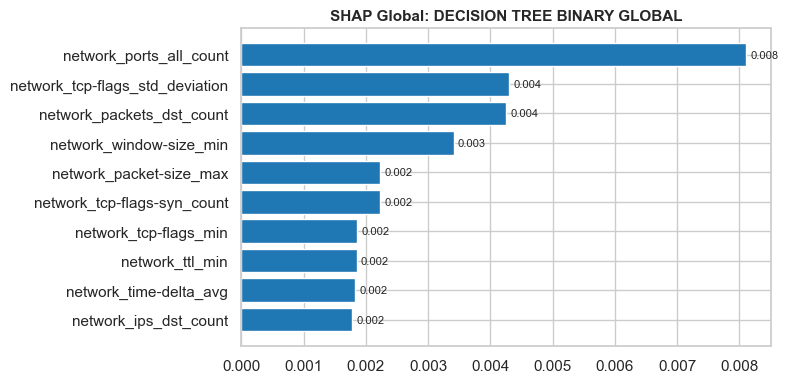

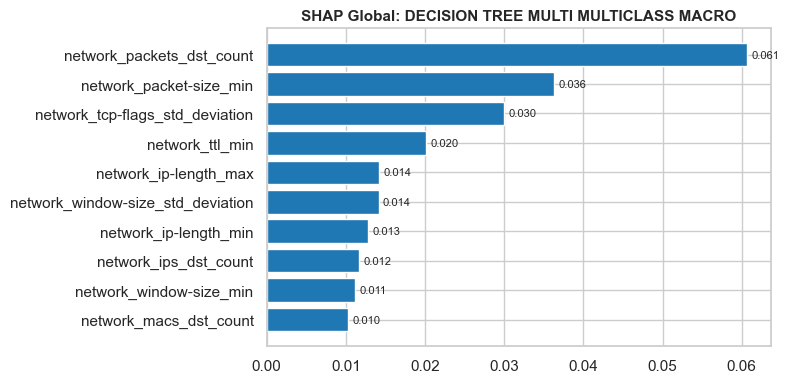

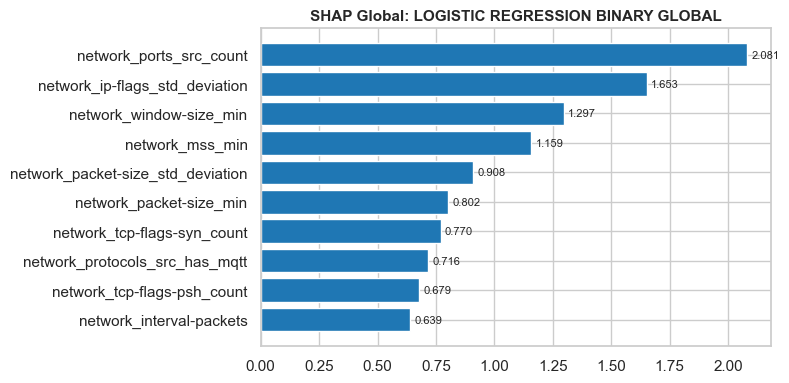

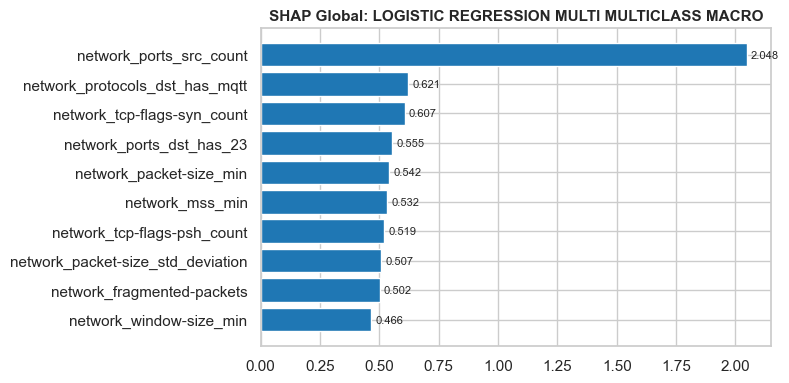

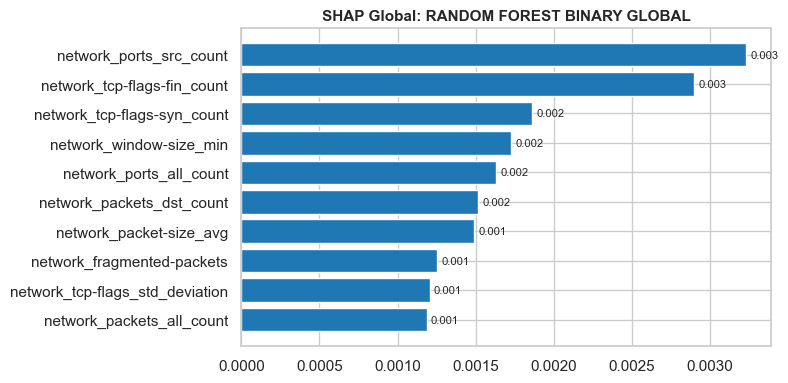

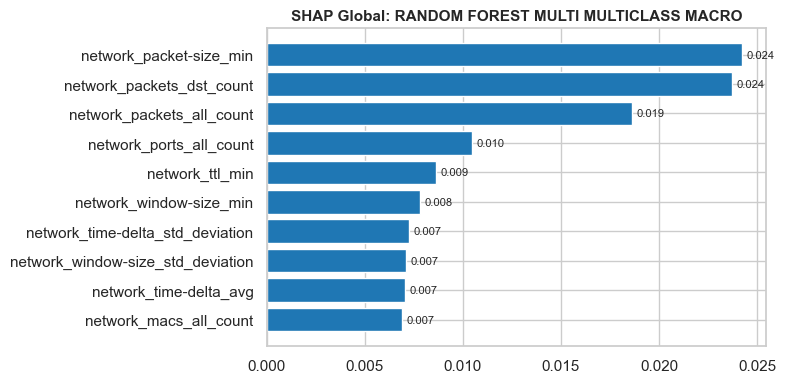


[TABELA MESTRA DE PERFORMANCE]


,Classe Alvo,True Positives (TP),False Positives (FP),False Negatives (FN),Modelo
0,benign,30717,2420,3483,decision_tree_multi
1,bruteforce,376,1877,89,decision_tree_multi
2,ddos,3962,154,539,decision_tree_multi
3,dos,4236,129,346,decision_tree_multi
4,malware,1691,452,197,decision_tree_multi
5,mitm,1762,331,256,decision_tree_multi
6,recon,6526,438,1919,decision_tree_multi
7,web,696,1031,3,decision_tree_multi
8,benign,27309,3469,6891,logistic_regression_multi
9,bruteforce,329,2641,136,logistic_regression_multi


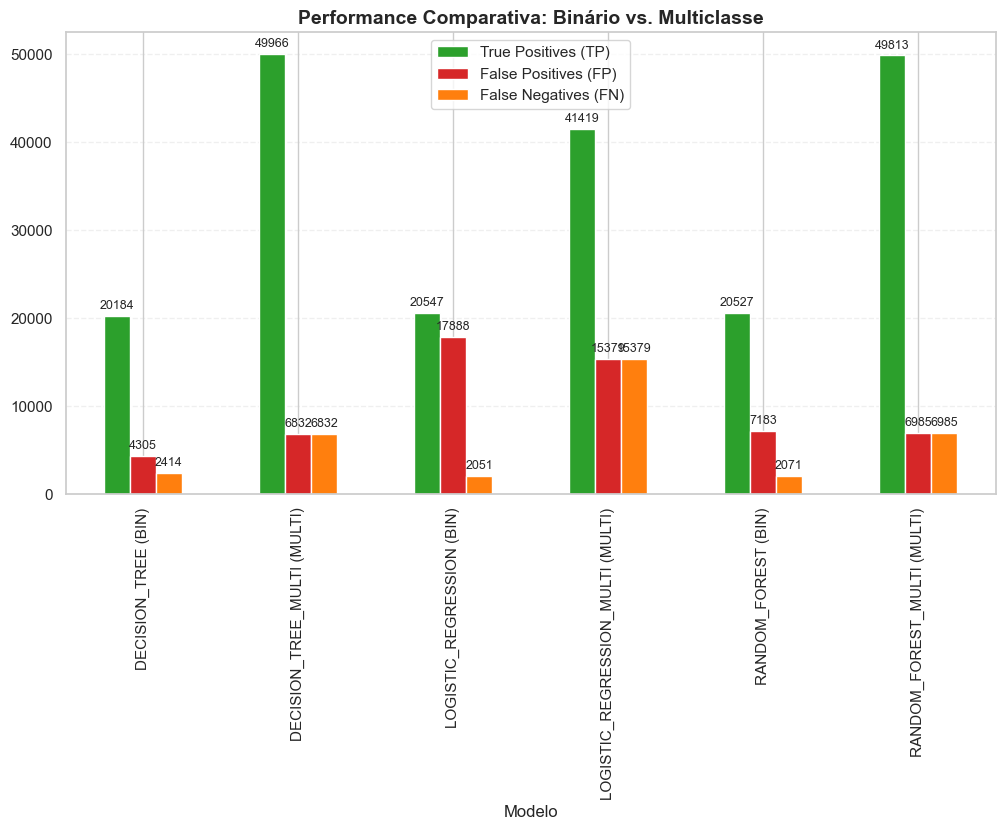


[RANKING DOS SUPER-DRIVERS DE ERRO - GLOBAL]

Top 5 Causadores de FPs:


,feature,FP_SHAP_Dir,FN_SHAP_Dir,Classes_Afetadas
12,network_packet-size_min,0.019148,0.016599,"dos, recon, malware"
7,network_ip-flags_avg,0.009820,0.005887,"recon, malware, ddos"
1,network_fragmented-packets,0.008063,0.005724,"bruteforce, recon, ddos"
11,network_mss_std_deviation,0.006498,0.012054,"benign, bruteforce, mitm"
0,network_fragmentation-score,0.006246,0.004029,"benign, ddos, recon"



Top 5 Causadores de FNs:


,feature,FP_SHAP_Dir,FN_SHAP_Dir,Classes_Afetadas
12,network_packet-size_min,0.019148,0.016599,"mitm, malware, benign"
11,network_mss_std_deviation,0.006498,0.012054,"mitm, dos, recon"
8,network_ip-flags_min,0.003305,0.011128,"ddos, dos, benign"
10,network_mss_min,0.004421,0.009807,"malware, dos, benign"
9,network_ip-flags_std_deviation,0.004318,0.007280,"recon, dos, mitm"


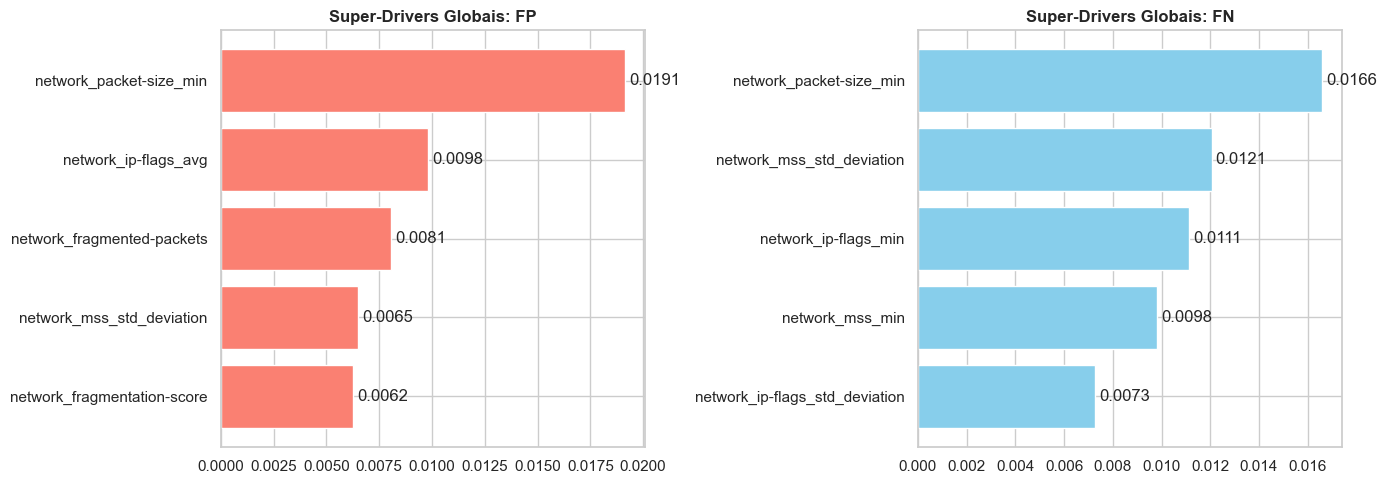

In [ ]:
# Definições de diretórios
XAI_DIR = Path.cwd().parent / "experiments" / "results_xai"
SHAP_GLOBAL_DIR = XAI_DIR / "shap_global"
FPFN_BINARY_DIR = XAI_DIR / "fpfn_binary"
FPFN_MULTI_DIR = XAI_DIR / "fpfn_multiclass"
FIG_ERRORS_DIR = XAI_DIR / "figures_errors"

print("="*80)
print("RELATÓRIO EXECUTIVO: SHAP GLOBAL + PERFORMANCE + FORENSE")
print("="*80)

# --- 1. PLOT SHAP GLOBAL (BINÁRIO E MULTICLASSE) ---
print("\n[EXIBINDO SHAP GLOBAL DOS MODELOS]")
for csv_file in SHAP_GLOBAL_DIR.glob("*.csv"):
    df = pd.read_csv(csv_file).head(10)
    col = "importance" if "importance" in df.columns else "importance_macro"
    
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(df["feature"].iloc[::-1], df[col].iloc[::-1], color="#1f77b4")
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
    plt.title(f"SHAP Global: {csv_file.stem.replace('_', ' ').upper()}", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()

# --- 2. RESUMO QUANTITATIVO (Tabela Mestra) ---
summary_data = [pd.read_csv(f).assign(Modelo=f.stem.replace("quantitativo_", "").replace("_final", "")) 
                for f in FPFN_MULTI_DIR.glob("quantitativo_*_final.csv")]
df_summary = pd.concat(summary_data, ignore_index=True)
print("\n[TABELA MESTRA DE PERFORMANCE]")
display(df_summary)

# --- 3. GRÁFICO COMPARATIVO DE PERFORMANCE (BIN + MULTI) ---
df_bin = pd.read_csv(FPFN_BINARY_DIR / "quantitativo_binary_global.csv").assign(Modelo=lambda x: x["Modelo"] + " (BIN)")
all_summary = [df_bin] + [pd.read_csv(f).assign(Modelo=f.stem.replace("quantitativo_", "").replace("_final", "").upper() + " (MULTI)") 
                          for f in FPFN_MULTI_DIR.glob("quantitativo_*_final.csv")]
df_total = pd.concat(all_summary, ignore_index=True)

df_plot = df_total.groupby("Modelo")[["True Positives (TP)", "False Positives (FP)", "False Negatives (FN)"]].sum()
ax = df_plot.plot(kind='bar', figsize=(12, 6), color=['#2ca02c', '#d62728', '#ff7f0e'])
for container in ax.containers: ax.bar_label(container, fmt='%d', padding=3, fontsize=9)
plt.title("Performance Comparativa: Binário vs. Multiclasse", fontsize=14, fontweight="bold")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

# --- 4. RANKING DE SUPER-DRIVERS + RELAÇÃO CLASSE-FEATURE ---
all_drivers = []
for diag_file in FPFN_MULTI_DIR.glob("*_error_diagnostic.csv"):
    df = pd.read_csv(diag_file)
    df["Classe_Relacionada"] = diag_file.stem.split('_')[-3]
    all_drivers.append(df[~df["feature"].str.contains("device|label", case=False)])

df_all_drivers = pd.concat(all_drivers, ignore_index=True)
df_ranking = df_all_drivers.groupby("feature")[["FP_SHAP_Dir", "FN_SHAP_Dir"]].apply(lambda x: x.abs().mean()).reset_index()

def get_related_classes(feature, col):
    return ", ".join(df_all_drivers[df_all_drivers["feature"] == feature].sort_values(col, ascending=False).head(3)["Classe_Relacionada"].unique())

print("\n[RANKING DOS SUPER-DRIVERS DE ERRO - GLOBAL]")
for col in ["FP_SHAP_Dir", "FN_SHAP_Dir"]:
    df_top = df_ranking.sort_values(col, ascending=False).head(5)
    df_top["Classes_Afetadas"] = df_top["feature"].apply(lambda x: get_related_classes(x, col))
    print(f"\nTop 5 Causadores de {col.split('_')[0]}s:")
    display(df_top)

# Plot Final do Ranking
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for i, col in enumerate(["FP_SHAP_Dir", "FN_SHAP_Dir"]):
    df_top = df_ranking.sort_values(col, ascending=False).head(5)
    ax[i].barh(df_top["feature"].iloc[::-1], df_top[col].iloc[::-1], color="salmon" if i==0 else "skyblue")
    ax[i].set_title(f"Super-Drivers Globais: {col.split('_')[0]}", fontweight="bold")
    ax[i].bar_label(ax[i].containers[0], fmt='%.4f', padding=3)
plt.tight_layout()
plt.show()